In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
url = "https://data.cityofchicago.org/resource/ajtu-isnz.csv?$limit=100000"

chicago_taxi_data = pd.read_csv(url)

print(chicago_taxi_data.shape)

(100000, 23)


In [ ]:
chicago_taxi_data = chicago_taxi_data.dropna()

print(chicago_taxi_data.shape)

(51125, 23)


In [ ]:
X = chicago_taxi_data.drop("trip_total", axis=1)

y = chicago_taxi_data["trip_total"]

In [ ]:
X = X.drop(
    [
        "trip_id",
        "taxi_id",
        "trip_start_timestamp",
        "trip_end_timestamp",
        "pickup_centroid_location",
        "dropoff_centroid_location"
    ],
    axis=1
)

In [ ]:
X = pd.get_dummies(
    X,
    columns=["payment_type", "company"],
    drop_first=True
)

In [ ]:
print(X.shape)
print(y.shape)

print(X.dtypes)

(51125, 48)
(51125,)
trip_seconds                                    float64
trip_miles                                      float64
pickup_census_tract                             float64
dropoff_census_tract                            float64
pickup_community_area                           float64
dropoff_community_area                          float64
fare                                            float64
tips                                            float64
tolls                                           float64
extras                                          float64
pickup_centroid_latitude                        float64
pickup_centroid_longitude                       float64
dropoff_centroid_latitude                       float64
dropoff_centroid_longitude                      float64
payment_type_Credit Card                           bool
payment_type_Dispute                               bool
payment_type_Mobile                                bool
payment_type_No Charge     

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(40900, 48)
(10225, 48)
(40900,)
(10225,)


In [ ]:
model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

print(y_pred[:5])

[94.41721883 11.51121787 30.6194717  10.12853683 64.10750276]


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9998952296840243
MAE: 0.08034104955750804


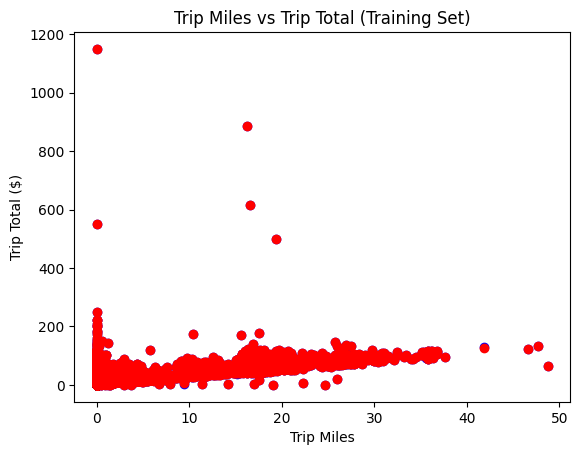

In [ ]:
plt.scatter(
    x_train["trip_miles"],
    y_train,
    color="blue"
)

plt.scatter(
    x_train["trip_miles"],
    model.predict(x_train),
    color="red"
)

plt.title("Trip Miles vs Trip Total (Training Set)")
plt.xlabel("Trip Miles")
plt.ylabel("Trip Total ($)")
plt.show()

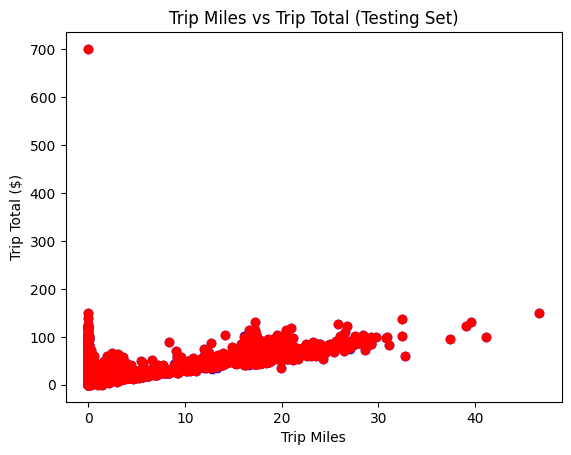

In [ ]:
plt.scatter(
    x_test["trip_miles"],
    y_test,
    color="blue"
)

plt.scatter(
    x_test["trip_miles"],
    model.predict(x_test),
    color="red"
)

plt.title("Trip Miles vs Trip Total (Testing Set)")
plt.xlabel("Trip Miles")
plt.ylabel("Trip Total ($)")
plt.show()